### TP 4

Muy bueno el código!

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score, roc_auc_score, confusion_matrix, roc_curve

# Cargar base original desde tu ruta
df = pd.read_stata("/Users/tomaspacheco/Documents/GitHub/E337-Grupo3/TP3/responieron_tp3.dta")
#df = pd.read_stata(r"C:\Users\caval\Desktop\otoño25'\bigdata\tp4\responieron_tp3.dta")

# Crear la variable binaria
df['desocupado'] = df['estado'].apply(lambda x: 1 if x == 2 else 0)

# Filtrar por año
df_2004 = df[df['ano4'] == 2004]
df_2024 = df[df['ano4'] == 2024]

# Función de split
def split_data(df):
    X = df[['edad_cuad', 'experiencia_pot', 'edad_x_exp', 'log_ing', 'ingreso_sin_subsidio', 'anos_educacion']]
    y = df['desocupado']
    return train_test_split(X, y, test_size=0.3, random_state=444)


# Split para 2004
X_train_2004, X_test_2004, y_train_2004, y_test_2004 = split_data(df_2004)

# Split para 2024
X_train_2024, X_test_2024, y_train_2024, y_test_2024 = split_data(df_2024)


/var/folders/_t/mb603w6j5pnb26rgk4q_j3_m0000gn/T/ipykernel_11915/594584983.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['desocupado'] = df['estado'].apply(lambda x: 1 if x == 2 else 0)


In [19]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split

## COMENTARIO TOMI: siempre es más comodo importar todos los paquetes al inicio


# --- Imputar faltantes con la media ---
imputer = SimpleImputer(strategy='mean')
X_train_2004_imputed = pd.DataFrame(imputer.fit_transform(X_train_2004), columns=X_train_2004.columns)
X_test_2004_imputed = pd.DataFrame(imputer.transform(X_test_2004), columns=X_test_2004.columns)

# --- Definir modelos ---
model_lasso = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, random_state=444)
model_ridge = LogisticRegression(penalty='l2', solver='liblinear', C=1.0, random_state=444)

# --- Entrenar modelos ---
model_lasso.fit(X_train_2004_imputed, y_train_2004)
model_ridge.fit(X_train_2004_imputed, y_train_2004)

# --- Predicciones ---
pred_lasso = model_lasso.predict(X_test_2004_imputed)
proba_lasso = model_lasso.predict_proba(X_test_2004_imputed)[:, 1]

pred_ridge = model_ridge.predict(X_test_2004_imputed)
proba_ridge = model_ridge.predict_proba(X_test_2004_imputed)[:, 1]

# --- Métricas ---
print("=== LASSO ===")
print("Accuracy:", round(accuracy_score(y_test_2004, pred_lasso), 3))
print("AUC:", round(roc_auc_score(y_test_2004, proba_lasso), 3))
print("Coeficientes:")
print(pd.Series(model_lasso.coef_[0], index=X_train_2004.columns).round(3))

print("\n=== RIDGE ===")
print("Accuracy:", round(accuracy_score(y_test_2004, pred_ridge), 3))
print("AUC:", round(roc_auc_score(y_test_2004, proba_ridge), 3))
print("Coeficientes:")
print(pd.Series(model_ridge.coef_[0], index=X_train_2004.columns).round(3))

=== LASSO ===
Accuracy: 0.966
AUC: 0.599
Coeficientes:
edad_cuad              -0.001
experiencia_pot        -0.028
edad_x_exp              0.001
log_ing                -0.296
ingreso_sin_subsidio    0.000
anos_educacion          0.023
dtype: float64

=== RIDGE ===
Accuracy: 0.966
AUC: 0.561
Coeficientes:
edad_cuad              -0.006
experiencia_pot        -0.041
edad_x_exp              0.007
log_ing                -0.062
ingreso_sin_subsidio    0.000
anos_educacion         -0.004
dtype: float64


Matriz de confusión - LASSO:
 [[564   0]
 [ 20   0]]
Matriz de confusión - Ridge:
 [[564   0]
 [ 20   0]]


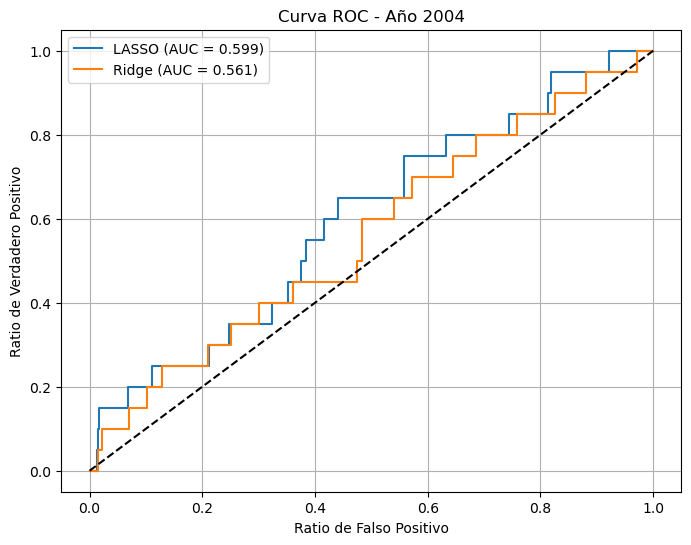

In [21]:
from sklearn.metrics import confusion_matrix, roc_curve
import matplotlib.pyplot as plt

# === MATRICES DE CONFUSIÓN ===
cm_lasso = confusion_matrix(y_test_2004, pred_lasso)
cm_ridge = confusion_matrix(y_test_2004, pred_ridge)

print("Matriz de confusión - LASSO:\n", cm_lasso)
print("Matriz de confusión - Ridge:\n", cm_ridge)

# === CURVAS ROC ===
fpr_lasso, tpr_lasso, _ = roc_curve(y_test_2004, proba_lasso)
fpr_ridge, tpr_ridge, _ = roc_curve(y_test_2004, proba_ridge)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lasso, tpr_lasso, label=f"LASSO (AUC = {roc_auc_score(y_test_2004, proba_lasso):.3f})")
plt.plot(fpr_ridge, tpr_ridge, label=f"Ridge (AUC = {roc_auc_score(y_test_2004, proba_ridge):.3f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("Ratio de Falso Positivo")
plt.ylabel("Ratio de Verdadero Positivo")
plt.title("Curva ROC - Año 2004")
plt.legend()
plt.grid(True)
plt.show()


=== LASSO 2024 ===
Accuracy: 0.977
AUC: 0.804
Coeficientes:
edad_cuad              -0.001
experiencia_pot         0.055
edad_x_exp             -0.000
log_ing                -0.295
ingreso_sin_subsidio   -0.000
anos_educacion          0.016
dtype: float64

=== RIDGE 2024 ===
Accuracy: 0.977
AUC: 0.726
Coeficientes:
edad_cuad              -0.010
experiencia_pot        -0.002
edad_x_exp              0.010
log_ing                -0.006
ingreso_sin_subsidio   -0.000
anos_educacion         -0.005
dtype: float64

Matriz de confusión - LASSO:
 [[887   0]
 [ 21   0]]
Matriz de confusión - Ridge:
 [[887   0]
 [ 21   0]]


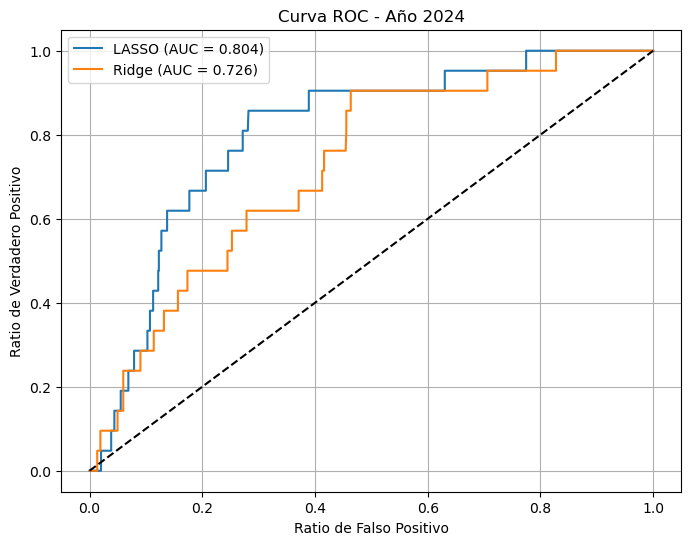

In [23]:
# --- Imputar faltantes con la media ---
X_train_2024_imputed = pd.DataFrame(imputer.fit_transform(X_train_2024), columns=X_train_2024.columns)
X_test_2024_imputed = pd.DataFrame(imputer.transform(X_test_2024), columns=X_test_2024.columns)

# --- Definir modelos ---
model_lasso_2024 = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, random_state=444)
model_ridge_2024 = LogisticRegression(penalty='l2', solver='liblinear', C=1.0, random_state=444)

# --- Entrenar ---
model_lasso_2024.fit(X_train_2024_imputed, y_train_2024)
model_ridge_2024.fit(X_train_2024_imputed, y_train_2024)

# --- Predicciones y probabilidades ---
pred_lasso_2024 = model_lasso_2024.predict(X_test_2024_imputed)
proba_lasso_2024 = model_lasso_2024.predict_proba(X_test_2024_imputed)[:, 1]

pred_ridge_2024 = model_ridge_2024.predict(X_test_2024_imputed)
proba_ridge_2024 = model_ridge_2024.predict_proba(X_test_2024_imputed)[:, 1]

# --- Métricas ---
print("=== LASSO 2024 ===")
print("Accuracy:", round(accuracy_score(y_test_2024, pred_lasso_2024), 3))
print("AUC:", round(roc_auc_score(y_test_2024, proba_lasso_2024), 3))
print("Coeficientes:")
print(pd.Series(model_lasso_2024.coef_[0], index=X_train_2024.columns).round(3))

print("\n=== RIDGE 2024 ===")
print("Accuracy:", round(accuracy_score(y_test_2024, pred_ridge_2024), 3))
print("AUC:", round(roc_auc_score(y_test_2024, proba_ridge_2024), 3))
print("Coeficientes:")
print(pd.Series(model_ridge_2024.coef_[0], index=X_train_2024.columns).round(3))

# --- MATRICES DE CONFUSIÓN ---
cm_lasso_2024 = confusion_matrix(y_test_2024, pred_lasso_2024)
cm_ridge_2024 = confusion_matrix(y_test_2024, pred_ridge_2024)

print("\nMatriz de confusión - LASSO:\n", cm_lasso_2024)
print("Matriz de confusión - Ridge:\n", cm_ridge_2024)

# --- CURVAS ROC ---
fpr_lasso_2024, tpr_lasso_2024, _ = roc_curve(y_test_2024, proba_lasso_2024)
fpr_ridge_2024, tpr_ridge_2024, _ = roc_curve(y_test_2024, proba_ridge_2024)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lasso_2024, tpr_lasso_2024, label=f"LASSO (AUC = {roc_auc_score(y_test_2024, proba_lasso_2024):.3f})")
plt.plot(fpr_ridge_2024, tpr_ridge_2024, label=f"Ridge (AUC = {roc_auc_score(y_test_2024, proba_ridge_2024):.3f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("Ratio de Falso Positivo")
plt.ylabel("Ratio de Verdadero Positivo")
plt.title("Curva ROC - Año 2024")
plt.legend()
plt.grid(True)
plt.show()


In [33]:
#Hacemos los valores del TP3 nuevamente (porque queremos imputar la media)
from sklearn.linear_model import LogisticRegression

# --- Modelo sin penalización para 2004 ---
logit_nopenalty_2004 = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000, random_state=444)
logit_nopenalty_2004.fit(X_train_2004_imputed, y_train_2004)
pred_np_2004 = logit_nopenalty_2004.predict(X_test_2004_imputed)
proba_np_2004 = logit_nopenalty_2004.predict_proba(X_test_2004_imputed)[:, 1]

# --- Modelo sin penalización para 2024 ---
logit_nopenalty_2024 = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000, random_state=444)
logit_nopenalty_2024.fit(X_train_2024_imputed, y_train_2024)
pred_np_2024 = logit_nopenalty_2024.predict(X_test_2024_imputed)
proba_np_2024 = logit_nopenalty_2024.predict_proba(X_test_2024_imputed)[:, 1]

# --- Métricas ---
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

print("=== 2004: Logistic Regression sin penalización ===")
print("Accuracy:", round(accuracy_score(y_test_2004, pred_np_2004), 3))
print("AUC:", round(roc_auc_score(y_test_2004, proba_np_2004), 3))
print("Matriz de confusión:\n", confusion_matrix(y_test_2004, pred_np_2004))

print("\n=== 2024: Logistic Regression sin penalización ===")
print("Accuracy:", round(accuracy_score(y_test_2024, pred_np_2024), 3))
print("AUC:", round(roc_auc_score(y_test_2024, proba_np_2024), 3))
print("Matriz de confusión:\n", confusion_matrix(y_test_2024, pred_np_2024))



=== 2004: Logistic Regression sin penalización ===
Accuracy: 0.966
AUC: 0.667
Matriz de confusión:
 [[564   0]
 [ 20   0]]

=== 2024: Logistic Regression sin penalización ===
Accuracy: 0.977
AUC: 0.816
Matriz de confusión:
 [[887   0]
 [ 21   0]]


Punto 4

Año 2004:
  λ* LASSO = 0.00001 (MSE = 0.03156)
  λ* Ridge = 0.00001 (MSE = 0.03156)



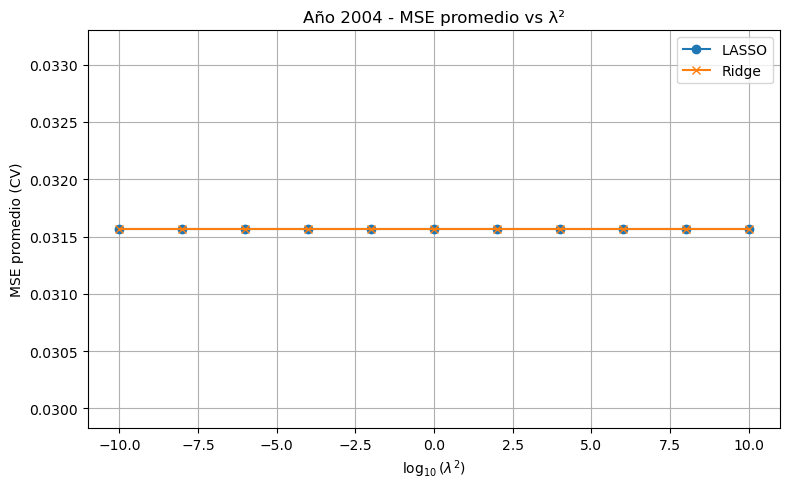

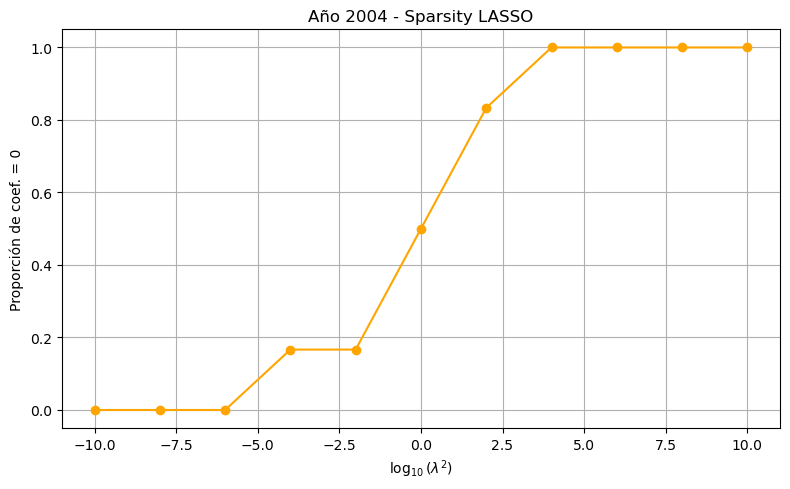

Año 2024:
  λ* LASSO = 0.00001 (MSE = 0.01559)
  λ* Ridge = 0.00001 (MSE = 0.01559)



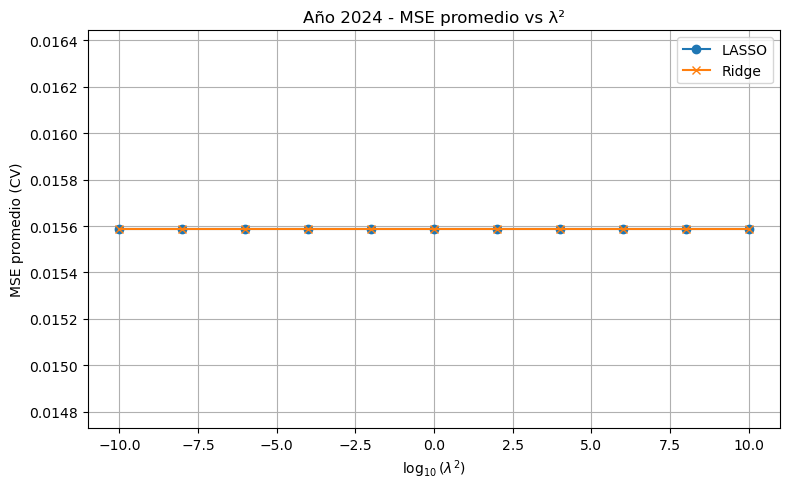

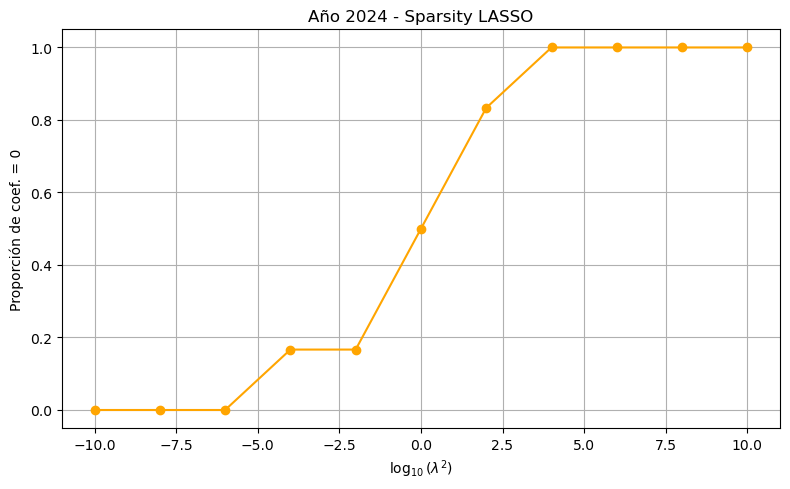

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# --- Definir valores de lambda y sus inversos C ---
lambdas = np.logspace(-5, 5, 11)
Cs = 1 / lambdas

# --- Organizar los datos por año ---
years_data = {
    "2004": (X_train_2004, y_train_2004),
    "2024": (X_train_2024, y_train_2024)
}

results_mse = {}

for year, (X_train, y_train) in years_data.items():
    y_train = y_train.values.ravel()

    # Imputar y escalar
    imputer = SimpleImputer(strategy="mean")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(imputer.fit_transform(X_train))

    mse_lasso = []
    mse_ridge = []
    sparsity_lasso = []

    for C in Cs:
        # LASSO
        lasso = LogisticRegression(penalty='l1', solver='liblinear', C=C, max_iter=1000)
        mse_scores_lasso = cross_val_score(lasso, X_train_scaled, y_train, cv=10, scoring='neg_mean_squared_error')
        mse_lasso.append(-np.mean(mse_scores_lasso))

        # Sparsity
        lasso.fit(X_train_scaled, y_train)
        sparsity_lasso.append(np.mean(lasso.coef_ == 0))

        # RIDGE
        ridge = LogisticRegression(penalty='l2', solver='liblinear', C=C, max_iter=1000)
        mse_scores_ridge = cross_val_score(ridge, X_train_scaled, y_train, cv=10, scoring='neg_mean_squared_error')
        mse_ridge.append(-np.mean(mse_scores_ridge))

    # Guardar resultados
    results_mse[year] = {
        "mse_lasso": mse_lasso,
        "mse_ridge": mse_ridge,
        "sparsity_lasso": sparsity_lasso
    }

    # Obtener el lambda óptimo (mínimo MSE) para cada año y método
for year in results_mse:
    mse_lasso = results_mse[year]["mse_lasso"]
    mse_ridge = results_mse[year]["mse_ridge"]

    idx_lasso = np.argmin(mse_lasso)
    idx_ridge = np.argmin(mse_ridge)

    print(f"Año {year}:")
    print(f"  λ* LASSO = {lambdas[idx_lasso]:.5f} (MSE = {mse_lasso[idx_lasso]:.5f})")
    print(f"  λ* Ridge = {lambdas[idx_ridge]:.5f} (MSE = {mse_ridge[idx_ridge]:.5f})")
    print()

    # --- Gráfico MSE promedio ---
    plt.figure(figsize=(8, 5))
    plt.plot(np.log10(lambdas**2), mse_lasso, marker='o', label='LASSO')
    plt.plot(np.log10(lambdas**2), mse_ridge, marker='x', label='Ridge')
    plt.xlabel(r"$\log_{10}(\lambda^2)$")
    plt.ylabel("MSE promedio (CV)")
    plt.title(f"Año {year} - MSE promedio vs λ²")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- Gráfico sparsity LASSO ---
    plt.figure(figsize=(8, 5))
    plt.plot(np.log10(lambdas**2), sparsity_lasso, marker='o', color='orange')
    plt.xlabel(r"$\log_{10}(\lambda^2)$")
    plt.ylabel("Proporción de coef. = 0")
    plt.title(f"Año {year} - Sparsity LASSO")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [39]:

#### COMENTARIO TOMI: me parece que faltaba este paquete:
from sklearn.linear_model import LogisticRegressionCV


# Faltaba importar StandardScaler, corregimos eso ahora
from sklearn.preprocessing import StandardScaler

# Reejecutar la parte del código donde falló por falta de importación
# Volvemos a correr el análisis CV para LASSO y Ridge usando log loss como métrica

# Definir valores de lambda y Cs
lambdas = np.logspace(-5, 5, 11)
Cs = 1 / lambdas
years_data = {
    "2004": (X_train_2004, y_train_2004),
    "2024": (X_train_2024, y_train_2024)
}

# Guardar resultados
results = {}

for year, (X_train, y_train) in years_data.items():
    print(f"\n--- Año {year} ---")

    y_train = y_train.values.ravel()

    imputer = SimpleImputer(strategy="mean")
    X_train_imputed = imputer.fit_transform(X_train)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_imputed)

    # LASSO
    lasso_cv = LogisticRegressionCV(
        Cs=Cs, cv=10, penalty='l1', solver='liblinear',
        scoring='neg_log_loss', max_iter=1000, random_state=444
    ).fit(X_train_scaled, y_train)

    # Ridge
    ridge_cv = LogisticRegressionCV(
        Cs=Cs, cv=10, penalty='l2', solver='liblinear',
        scoring='neg_log_loss', max_iter=1000, random_state=444
    ).fit(X_train_scaled, y_train)

    # Log loss medios
    logloss_lasso = -np.mean(lasso_cv.scores_[1], axis=0)
    logloss_ridge = -np.mean(ridge_cv.scores_[1], axis=0)

    # Sparsity
    coef_zero_ratio = []
    for c in Cs:
        model = LogisticRegression(penalty='l1', solver='liblinear', C=c, max_iter=1000, random_state=444)
        model.fit(X_train_scaled, y_train)
        coef_zero_ratio.append(np.mean(model.coef_ == 0))

    results[year] = {
        "logloss_lasso": logloss_lasso,
        "logloss_ridge": logloss_ridge,
        "coef_zero_ratio": coef_zero_ratio,
        "lambda_opt_lasso": 1 / lasso_cv.C_[0],
        "lambda_opt_ridge": 1 / ridge_cv.C_[0]
    }

results



--- Año 2004 ---

--- Año 2024 ---


{'2004': {'logloss_lasso': array([0.12552846, 0.12552893, 0.12553527, 0.12561356, 0.12613381,
         0.12743284, 0.13118694, 0.18508062, 0.69314718, 0.69314718,
         0.69314718]),
  'logloss_ridge': array([0.12552777, 0.12552681, 0.12552099, 0.12556933, 0.12565353,
         0.12550165, 0.13544037, 0.22800998, 0.51037534, 0.66741568,
         0.69046746]),
  'coef_zero_ratio': [0.0,
   0.0,
   0.0,
   0.0,
   0.16666666666666666,
   0.3333333333333333,
   0.6666666666666666,
   1.0,
   1.0,
   1.0,
   1.0],
  'lambda_opt_lasso': 1e-05,
  'lambda_opt_ridge': 1.0},
 '2024': {'logloss_lasso': array([0.07280665, 0.07280653, 0.0727977 , 0.07271632, 0.07248011,
         0.07177117, 0.07403691, 0.11129294, 0.69314718, 0.69314718,
         0.69314718]),
  'logloss_ridge': array([0.07281021, 0.07280716, 0.07277996, 0.07263185, 0.07219634,
         0.07208889, 0.08050301, 0.15729545, 0.43602245, 0.65142617,
         0.68870675]),
  'coef_zero_ratio': [0.0,
   0.0,
   0.0,
   0.1666666666666

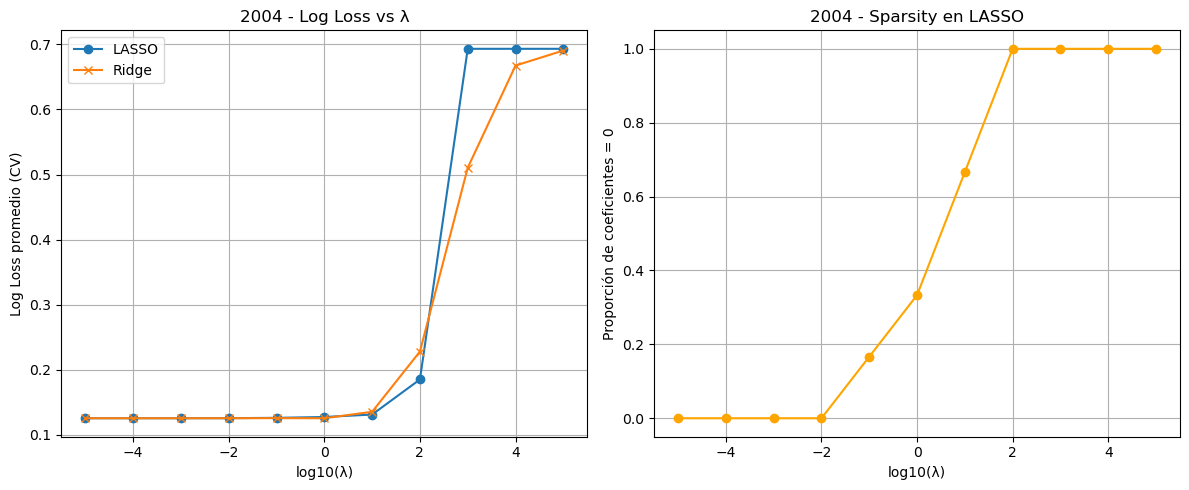

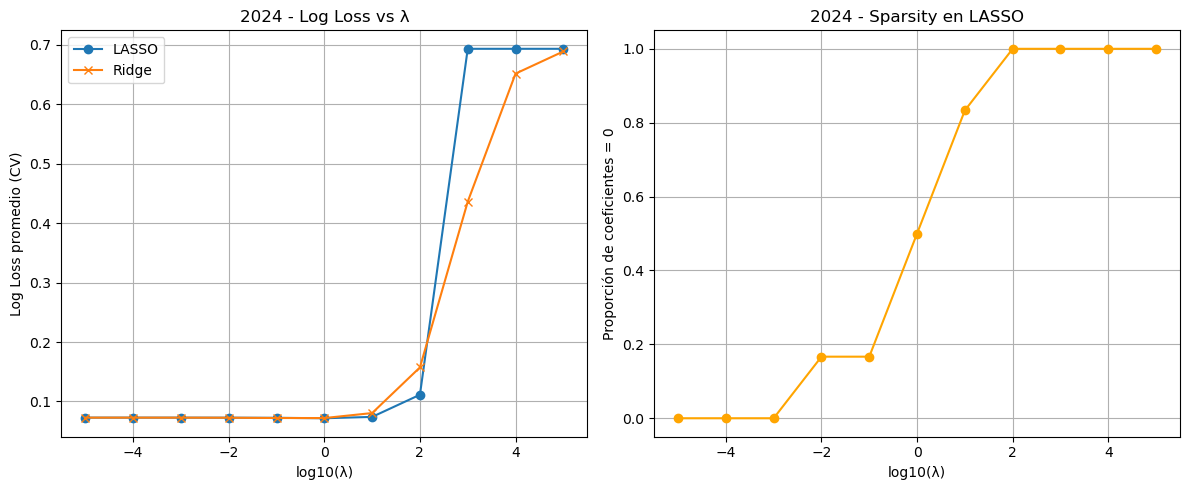

In [41]:
# Graficar log loss y sparsity para ambos años

for year in ["2004", "2024"]:
    logloss_lasso = results[year]["logloss_lasso"]
    logloss_ridge = results[year]["logloss_ridge"]
    coef_zero_ratio = results[year]["coef_zero_ratio"]

    plt.figure(figsize=(12, 5))

    # Log Loss
    plt.subplot(1, 2, 1)
    plt.plot(np.log10(lambdas), logloss_lasso, marker='o', label="LASSO")
    plt.plot(np.log10(lambdas), logloss_ridge, marker='x', label="Ridge")
    plt.xlabel("log10(λ)")
    plt.ylabel("Log Loss promedio (CV)")
    plt.title(f"{year} - Log Loss vs λ")
    plt.legend()
    plt.grid(True)

    # Sparsity
    plt.subplot(1, 2, 2)
    plt.plot(np.log10(lambdas), coef_zero_ratio, marker='o', color='orange')
    plt.xlabel("log10(λ)")
    plt.ylabel("Proporción de coeficientes = 0")
    plt.title(f"{year} - Sparsity en LASSO")
    plt.grid(True)

    plt.tight_layout()
    plt.show()


Punto 5

In [45]:
from sklearn.linear_model import LogisticRegression
import pandas as pd

# C correspondiente a lambda = 10^-5
C_opt = 1e5

# Ajuste para 2004
lasso_2004 = LogisticRegression(penalty='l1', solver='liblinear', C=C_opt, max_iter=1000)
lasso_2004.fit(X_train_2004_imputed, y_train_2004)

np_2004 = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000)
np_2004.fit(X_train_2004_imputed, y_train_2004)

# Ajuste para 2024
lasso_2024 = LogisticRegression(penalty='l1', solver='liblinear', C=C_opt, max_iter=1000)
lasso_2024.fit(X_train_2024_imputed, y_train_2024)

np_2024 = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000)
np_2024.fit(X_train_2024_imputed, y_train_2024)

# Crear DataFrames de coeficientes
coef_2004 = pd.DataFrame({
    'Variable': X_train_2004_imputed.columns,
    'LASSO': lasso_2004.coef_[0],
    'TP3 (sin penalización)': np_2004.coef_[0]
}).set_index('Variable')

coef_2024 = pd.DataFrame({
    'Variable': X_train_2024_imputed.columns,
    'LASSO': lasso_2024.coef_[0],
    'TP3 (sin penalización)': np_2024.coef_[0]
}).set_index('Variable')

# Tabla combinada
coef_todos = pd.concat({"2004": coef_2004, "2024": coef_2024}, axis=1)

# Mostrar tabla
coef_todos



2004                             2024  \
                         LASSO TP3 (sin penalización)     LASSO   
Variable                                                          
edad_cuad            -0.002043              -0.003270 -0.000676   
experiencia_pot      -0.013250              -0.002667  0.106863   
edad_x_exp            0.002196               0.003430 -0.000946   
log_ing              -1.594721              -1.601650 -0.459784   
ingreso_sin_subsidio  0.000003               0.000003 -0.000009   
anos_educacion        0.056422               0.074868  0.030424   

                                             
                     TP3 (sin penalización)  
Variable                                     
edad_cuad                         -0.000824  
experiencia_pot                    0.115948  
edad_x_exp                        -0.000913  
log_ing                           -0.384266  
ingreso_sin_subsidio              -0.000009  
anos_educacion                     0.044209

Punto 7

Mejor profundidad para el año 2004: 1


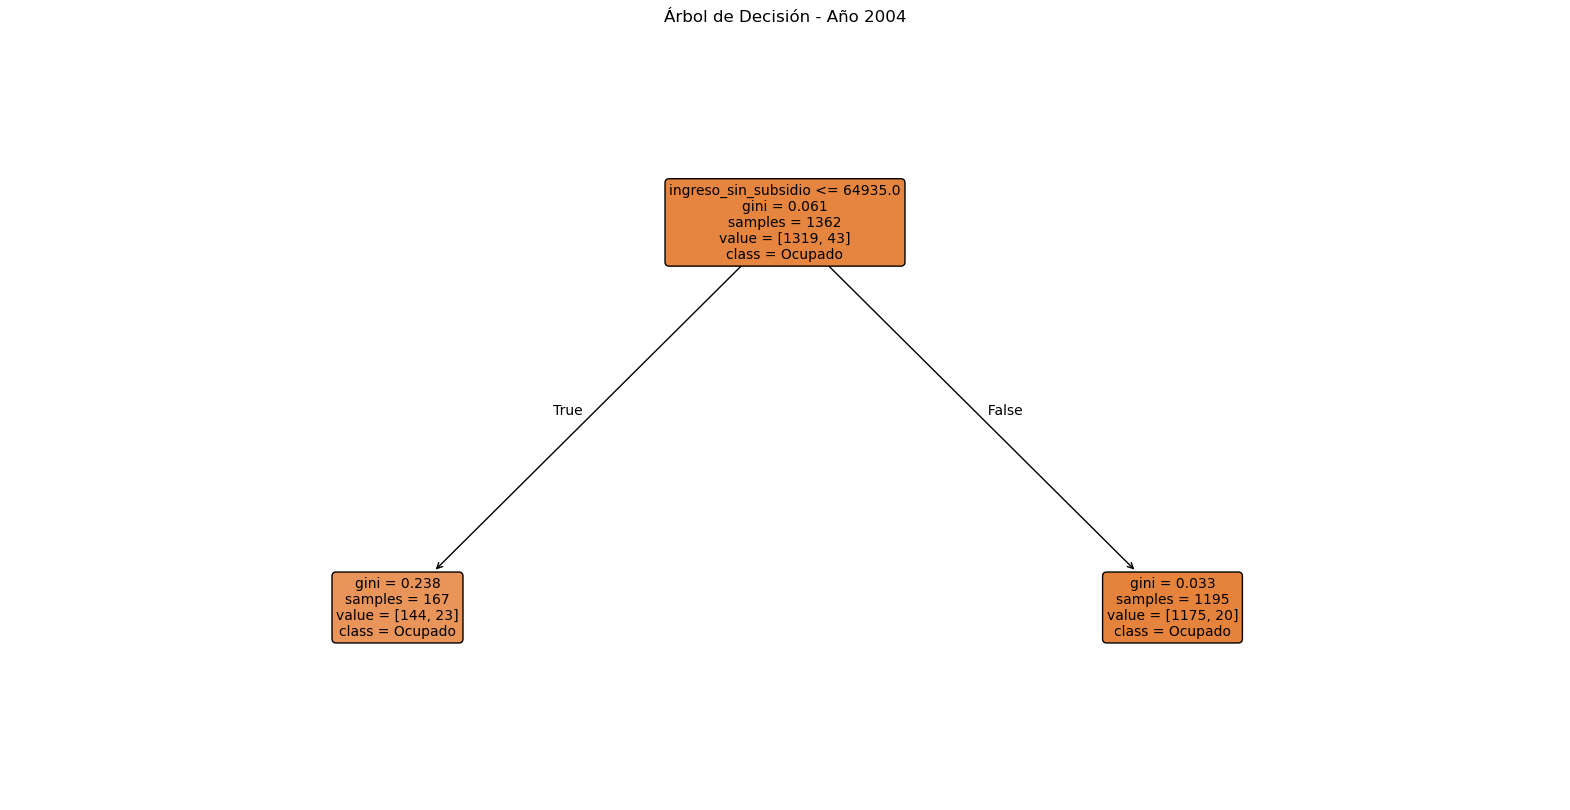

Mejor profundidad para el año 2024: 1


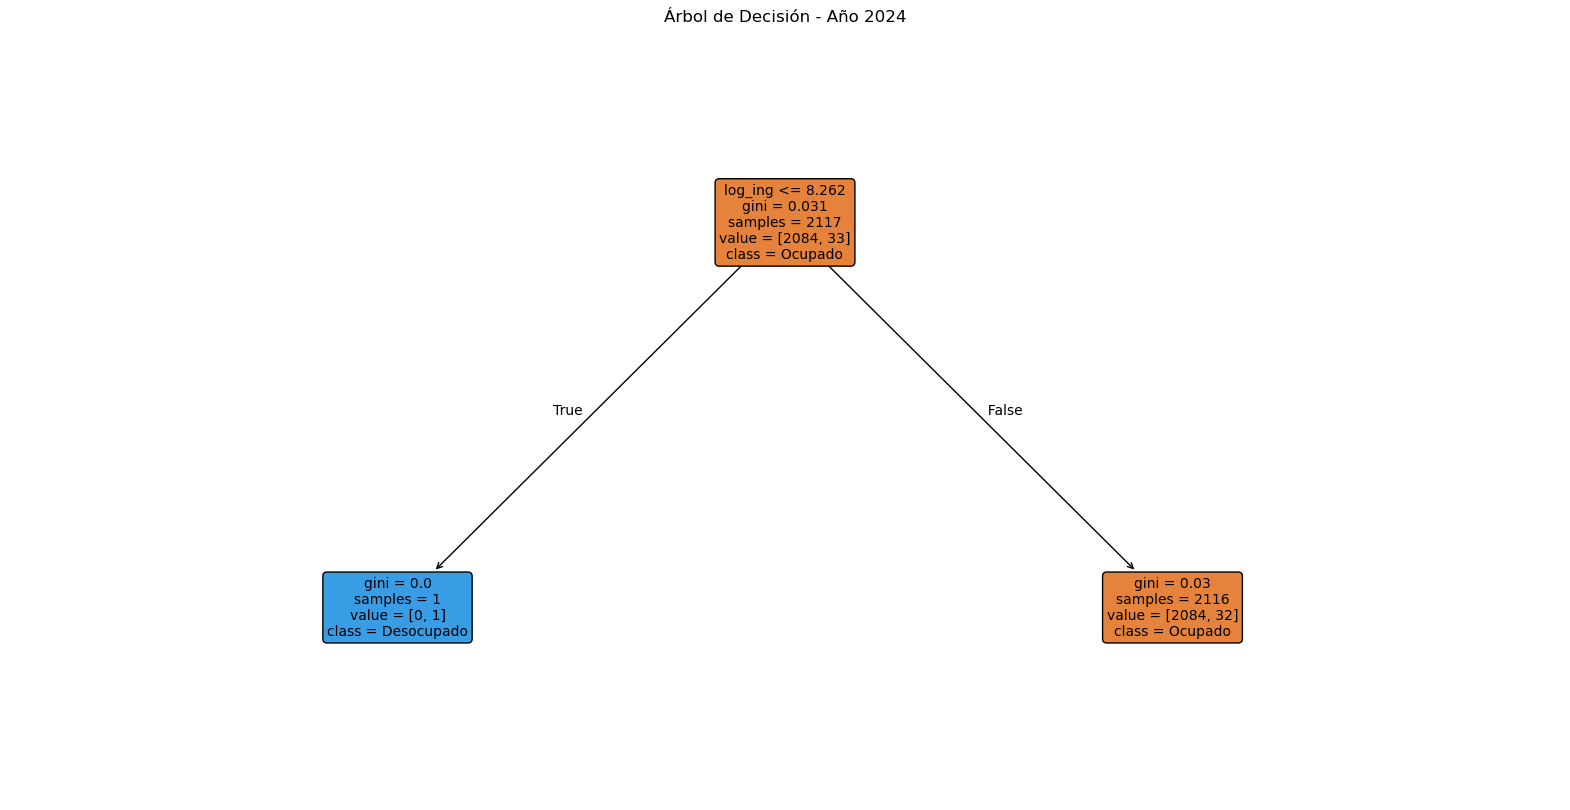

In [47]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV, cross_val_score
import matplotlib.pyplot as plt

def entrenar_y_graficar_CART(X_train, y_train, year):
    param_grid = {'max_depth': range(1, 21)}
    tree = DecisionTreeClassifier(random_state=42)
    grid_search = GridSearchCV(tree, param_grid, cv=10, scoring='accuracy')
    grid_search.fit(X_train, y_train)

    best_tree = grid_search.best_estimator_
    print(f"Mejor profundidad para el año {year}: {grid_search.best_params_['max_depth']}")

    plt.figure(figsize=(20, 10))
    plot_tree(
        best_tree,
        feature_names=X_train.columns,
        class_names=['Ocupado', 'Desocupado'],
        filled=True,
        rounded=True,
        fontsize=10,
        impurity=True
    )
    plt.title(f"Árbol de Decisión - Año {year}")
    plt.show()

    return best_tree


# Asumiendo que ya tenés definidos: X_train_2004, y_train_2004, X_train_2024, y_train_2024
tree_2004 = entrenar_y_graficar_CART(X_train_2004, y_train_2004, 2004)
tree_2024 = entrenar_y_graficar_CART(X_train_2024, y_train_2024, 2024)


Punto 8

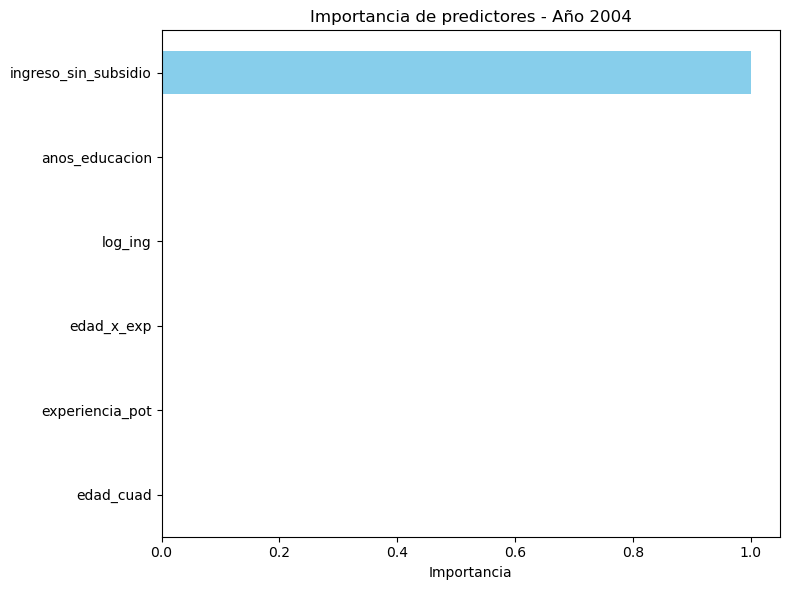

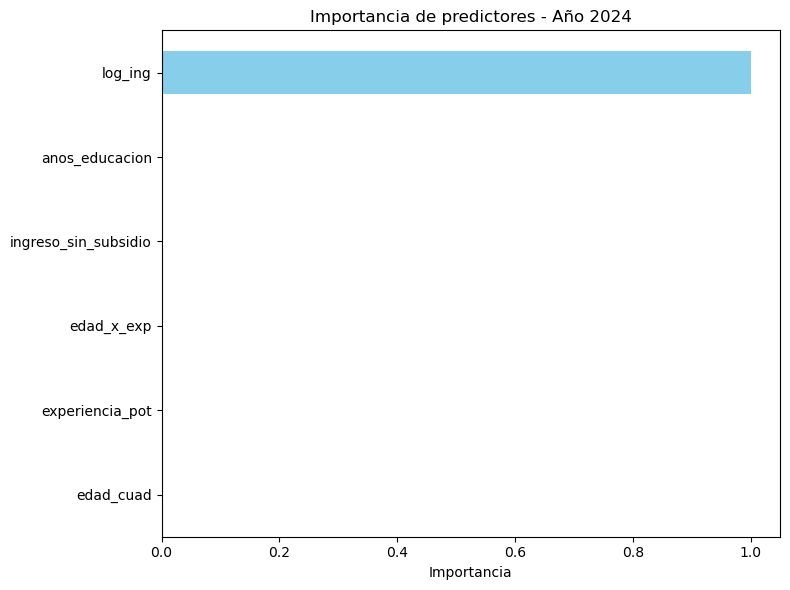

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

def graficar_importancia(tree_model, X_train, year):
    importancias = pd.Series(tree_model.feature_importances_, index=X_train.columns)
    importancias = importancias.sort_values(ascending=True)

    plt.figure(figsize=(8, 6))
    importancias.plot(kind='barh', color='skyblue')
    plt.title(f"Importancia de predictores - Año {year}")
    plt.xlabel("Importancia")
    plt.tight_layout()
    plt.savefig(f"importancia_variables_{year}.pdf")
    plt.show()

graficar_importancia(tree_2004, X_train_2004, 2004)
graficar_importancia(tree_2024, X_train_2024, 2024)

Punto 9

LASSO - Año 2024 | Accuracy: 0.9769 | AUC: 0.8041 | MSE: 0.0221

Matriz de Confusión - LASSO (texto):
[[887   0]
 [ 21   0]]



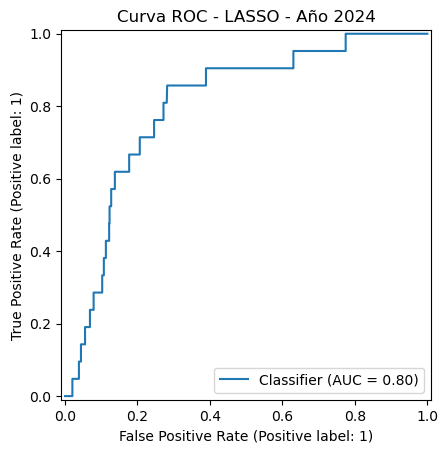

Ridge - Año 2024 | Accuracy: 0.9769 | AUC: 0.7262 | MSE: 0.0226

Matriz de Confusión - Ridge (texto):
[[887   0]
 [ 21   0]]



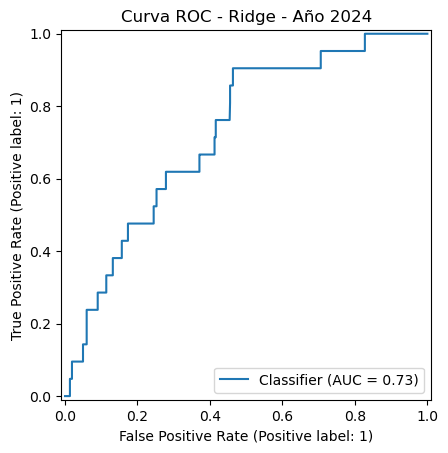

CART - Año 2004 | Accuracy: 0.9658 | AUC: 0.6174 | MSE: 0.0328

Matriz de Confusión - CART (texto):
[[564   0]
 [ 20   0]]



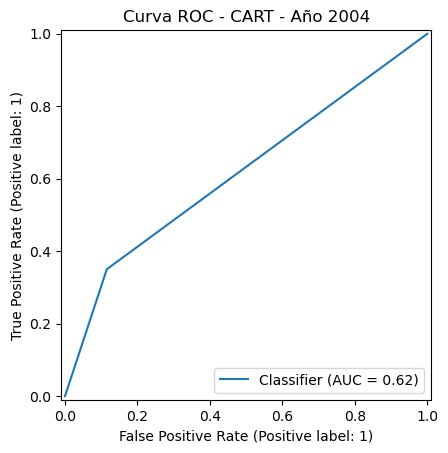

CART - Año 2024 | Accuracy: 0.9769 | AUC: 0.5000 | MSE: 0.0227

Matriz de Confusión - CART (texto):
[[887   0]
 [ 21   0]]



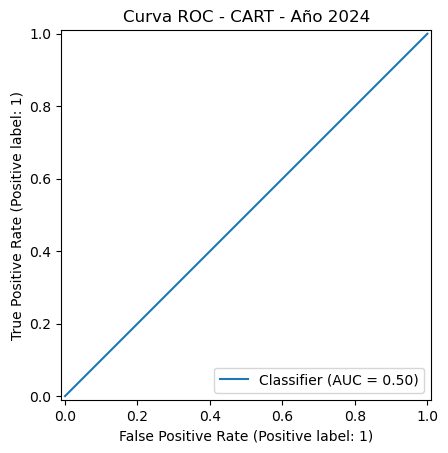

(0.9768722466960352, 0.5, 0.022656938434218163)

In [51]:
from sklearn.metrics import confusion_matrix, roc_curve, auc, accuracy_score, mean_squared_error, ConfusionMatrixDisplay, RocCurveDisplay
import matplotlib.pyplot as plt

def evaluar_modelo(nombre, modelo, X_test, y_test, year):
    y_pred = modelo.predict(X_test)
    
    # Si es un modelo lineal, puede devolver valores continuos (como Ridge)
    if hasattr(modelo, "predict_proba"):
        y_proba = modelo.predict_proba(X_test)[:, 1]
    else:
        try:
            y_proba = modelo.decision_function(X_test)
        except:
            y_proba = modelo.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_proba)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = auc(fpr, tpr)

    print(f"{nombre} - Año {year} | Accuracy: {acc:.4f} | AUC: {auc_score:.4f} | MSE: {mse:.4f}")

    # Matriz de confusión ---
    cm = confusion_matrix(y_test, y_pred)
    print(f"\nMatriz de Confusión - {nombre} (texto):\n{cm}\n")


    # Curva ROC
    RocCurveDisplay.from_predictions(y_test, y_proba)
    plt.title(f"Curva ROC - {nombre} - Año {year}")
    plt.savefig(f"roc_{nombre.lower()}_{year}.png", bbox_inches='tight')
    plt.show()

    return acc, auc_score, mse

evaluar_modelo("LASSO", model_lasso_2024, X_test_2024_imputed, y_test_2024, 2024)
evaluar_modelo("Ridge", model_ridge_2024, X_test_2024_imputed, y_test_2024, 2024)

evaluar_modelo("CART", tree_2004, X_test_2004, y_test_2004, 2004)
evaluar_modelo("CART", tree_2024, X_test_2024, y_test_2024, 2024)
